<center> <h2><b>3 Representation Learning</b></h2> </center>

In [123]:
import importlib
import sys
sys.path.append("..")  # Ensure the parent directory is in the path

import visualization.data_exploration_plots
import data_preprocessing.data_preprocessing
import models.classic_ml.classic_ml_models
import models.lstm_rnn.lstm_rnn

# Reload the module to reflect changes
importlib.reload(visualization.data_exploration_plots)
importlib.reload(data_preprocessing.data_preprocessing)
importlib.reload(models.classic_ml.classic_ml_models)
importlib.reload(models.lstm_rnn.lstm_rnn)

from data_preprocessing.data_cleaning import *
from models.classic_ml.classic_ml_models import *
from utils.data_loader import load_and_clean_data

import torch


from models.lstm_rnn.lstm_rnn import preprocess_for_lstm, build_lstm_model
import tensorflow as tf

from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np
from keras.utils import set_random_seed
from keras.src.callbacks import EarlyStopping, ReduceLROnPlateau

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
set_random_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else
                      "mps" if torch.mps.is_available() else
                      "cpu")
print(f"Using : {device}")

Using : mps


# Prepare Data

In [95]:
x_paths = ['set-a.parquet', 'set-b.parquet', 'set-c.parquet']
y_paths = ['outcomes-a.parquet', 'outcomes-b.parquet', 'outcomes-c.parquet']

X_train, X_valid, X_test, y_train, y_valid, y_test = load_and_clean_data(x_paths, y_paths, clean_data)

In [96]:
X_train.head(3)

,recordid,time,ALP,ALT,AST,Age,Albumin,BUN,Bilirubin,Cholesterol,...,RespRate,SaO2,SysABP,Temp,TroponinI,TroponinT,Urine,WBC,Weight,pH
0,132539,00:00,NaN,NaN,NaN,54,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,132539,01:00,NaN,NaN,NaN,54,NaN,NaN,NaN,NaN,...,19.0,NaN,NaN,35.6,NaN,NaN,60.0,NaN,NaN,NaN
2,132539,02:00,NaN,NaN,NaN,54,NaN,NaN,NaN,NaN,...,18.0,NaN,NaN,NaN,NaN,NaN,30.0,NaN,NaN,NaN


## Q3.1 Pretraining and Linear Probes

### Pretrain LSTM

In [97]:
X_train_lstm, X_valid_lstm, X_test_lstm = preprocess_for_lstm(X_train, X_valid, X_test)

In [98]:
X_train_lstm.shape

(4000, 49, 40)

In [125]:
lstm_pretrained_model = build_lstm_model((X_train_lstm.shape[1], X_train_lstm.shape[2]))

history = lstm_pretrained_model.fit(
    X_train_lstm, y_train,
    validation_data=(X_valid_lstm, y_valid),
    epochs=30,
    batch_size=32,
    verbose=1,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
    ]
)

y_test_pred = lstm_pretrained_model.predict(X_test_lstm).ravel()  # Flatten the predictions

test_auroc = roc_auc_score(y_test, y_test_pred)  # Use predicted probabilities for AUROC
test_auprc = average_precision_score(y_test, y_test_pred)  # Use predicted probabilities for AUPRC
print(f"Classical RNN Performance:")
print(f"AUROC: {test_auroc:.4f}")
print(f"AUPRC: {test_auprc:.4f}")

Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.7642 - loss: 2.1836 - precision_6: 0.2920 - recall_6: 0.3463 - val_accuracy: 0.8668 - val_loss: 1.1340 - val_precision_6: 0.5936 - val_recall_6: 0.1954 - learning_rate: 5.0000e-04
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8623 - loss: 1.0019 - precision_6: 0.6283 - recall_6: 0.1763 - val_accuracy: 0.8685 - val_loss: 0.6732 - val_precision_6: 0.5991 - val_recall_6: 0.2236 - learning_rate: 5.0000e-04
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8717 - loss: 0.6252 - precision_6: 0.6673 - recall_6: 0.2575 - val_accuracy: 0.8717 - val_loss: 0.5014 - val_precision_6: 0.6096 - val_recall_6: 0.2694 - learning_rate: 5.0000e-04
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8753 - loss: 0.4752 - precision_6: 0.6868 - recall_6: 0.2840 - val_accuracy: 0.8692 - val_loss: 0.4366 - val_precision_6: 0.5743 - val_recall_6: 0.3063 - learning_rate: 5.0000e-04
Epoch 5/30
1

In [127]:
from keras.models import Model

# Create embedding extractor model
embedding_model = Model(
    inputs=lstm_pretrained_model.input,
    outputs=lstm_pretrained_model.layers[-2].output  # Extract output from last LSTM layer
)

# Generate embeddings for training, validation, and test sets
X_train_embeddings = embedding_model.predict(X_train_lstm)
X_valid_embeddings = embedding_model.predict(X_valid_lstm)
X_test_embeddings = embedding_model.predict(X_test_lstm)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


### Freeze weights + Compute a single embedding vector for each patient + train a logistic regression

In [130]:
results_lr = train_and_evaluate_model('lr', X_train_embeddings, X_valid_embeddings, X_test_embeddings, y_train, y_valid, y_test)

In [131]:
results_lr

{'validation': {'auroc': 0.8270415763813651, 'auprc': 0.47707370945738553},
 'test': {'auroc': 0.8262632178298358, 'auprc': 0.4704657472237802}}

## Q3.2 Simulate label scarcity

In [109]:
# Define patient sample sizes
sample_sizes = [100, 500, 1000]

- Train three different supervised (as in Q2.x) models with the same (or as similar as
possible) architecture as your pretrained network, but only use 100, 500, and 1000
patients from the training set and report your full test set performance.

In [138]:
# Store results
results = {}

# Loop through different sample sizes
for sample_size in sample_sizes:
    print(f"\nTraining with sample size: {sample_size}")

    # Subsample training data
    indices = np.random.choice(len(X_train_lstm), sample_size, replace=False)  # Use index range
    X_train_sub = X_train_lstm[indices]  # Subsample features
    y_train_sub = y_train[indices]      # Subsample labels (use y_train, not X_train_lstm)

    # Build LSTM model
    lstm_model = build_lstm_model((X_train_sub.shape[1], X_train_sub.shape[2]))  # Ensure input shape is correct

    # Train the model on sub-sampled data
    history = lstm_model.fit(
        X_train_sub, y_train_sub,  # Train on subsampled data
        validation_data=(X_valid_lstm, y_valid),
        epochs=30,
        batch_size=32,
        verbose=1,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
        ]
    )

    # Evaluate on test set
    y_test_pred = lstm_model.predict(X_test_lstm).ravel()  # Flatten predictions
    test_auroc = roc_auc_score(y_test, y_test_pred)  # Compute AUROC
    test_auprc = average_precision_score(y_test, y_test_pred)  # Compute AUPRC

    # Store results
    results[sample_size] = {"AUROC": test_auroc, "AUPRC": test_auprc}

    # Print results for this sample size
    print(f"Performance with {sample_size} samples:")
    print(f"AUROC: {test_auroc:.4f} | AUPRC: {test_auprc:.4f}")

# Print summary of all runs
print("\nSummary of Results:")
for size, metrics in results.items():
    print(f"Sample Size {size}: AUROC = {metrics['AUROC']:.4f}, AUPRC = {metrics['AUPRC']:.4f}")


Training with sample size: 100
Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 281ms/step - accuracy: 0.4098 - loss: 2.7407 - precision_10: 0.1420 - recall_10: 0.3894 - val_accuracy: 0.5020 - val_loss: 2.6768 - val_precision_10: 0.0964 - val_recall_10: 0.2993 - learning_rate: 5.0000e-04
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 196ms/step - accuracy: 0.5728 - loss: 2.6448 - precision_10: 0.2072 - recall_10: 0.4079 - val_accuracy: 0.5993 - val_loss: 2.5995 - val_precision_10: 0.1088 - val_recall_10: 0.2535 - learning_rate: 5.0000e-04
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 201ms/step - accuracy: 0.7000 - loss: 2.5667 - precision_10: 0.3076 - recall_10: 0.4079 - val_accuracy: 0.6733 - val_loss: 2.5258 - val_precision_10: 0.1226 - val_recall_10: 0.2113 - learning_rate: 5.0000e-04
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 201ms/step - accuracy: 0.8176 - loss: 2.4874 - precision_10: 0.5429 - recall_10: 0.5375 - val_accuracy: 0.7295 - val_loss: 2.4534 - val_precision_10: 0.1536 - val_recall_10: 0.2007 - le

- Train three linear probes (as in Q3.1 step 2) using only 100, 500, 1000 labelled
patients and report the full test set C performance.

In [139]:
# Store results
results_lr = {}

for num_patients in sample_sizes:
    # Select a random subset of patients from X_train_compressed
    indices = np.random.choice(len(X_train_embeddings), num_patients, replace=False)
    X_train_subset = X_train_embeddings[indices]
    y_train_subset = y_train[indices]

    # Train and evaluate the model
    results_lr[num_patients] = train_and_evaluate_model('lr', X_train_subset, X_valid_embeddings, X_test_embeddings, y_train_subset, y_valid, y_test)

# Print results
for num, res in results_lr.items():
    print(f"Train Size: {num}")
    print(f"  Validation AUROC: {res['validation']['auroc']:.4f}, AUPRC: {res['validation']['auprc']:.4f}")
    print(f"  Test AUROC: {res['test']['auroc']:.4f}, AUPRC: {res['test']['auprc']:.4f}")
    print("-" * 50)

Train Size: 100
  Validation AUROC: 0.8255, AUPRC: 0.4716
  Test AUROC: 0.8238, AUPRC: 0.4680
--------------------------------------------------
Train Size: 500
  Validation AUROC: 0.8259, AUPRC: 0.4728
  Test AUROC: 0.8245, AUPRC: 0.4683
--------------------------------------------------
Train Size: 1000
  Validation AUROC: 0.8259, AUPRC: 0.4741
  Test AUROC: 0.8249, AUPRC: 0.4698
--------------------------------------------------


## Q.3.3 Visualising Learned Representations

Visualize your learned representations through a dimensionality reduction technique such as
t-SNE7 or UMAP8 (2 Pt).

Are data points with different labels distributed identically? (1 pt)


Use a quantitative clustering metric to assess the quality of your dimensionality reduction
w.r.t. target class labels (1 pt).

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 4000 samples in 0.000s...
[t-SNE] Computed neighbors for 4000 samples in 0.059s...
[t-SNE] Computed conditional probabilities for sample 1000 / 4000
[t-SNE] Computed conditional probabilities for sample 2000 / 4000
[t-SNE] Computed conditional probabilities for sample 3000 / 4000
[t-SNE] Computed conditional probabilities for sample 4000 / 4000
[t-SNE] Mean sigma: 0.008397
[t-SNE] KL divergence after 250 iterations with early exaggeration: 60.895226
[t-SNE] KL divergence after 1000 iterations: 0.680013


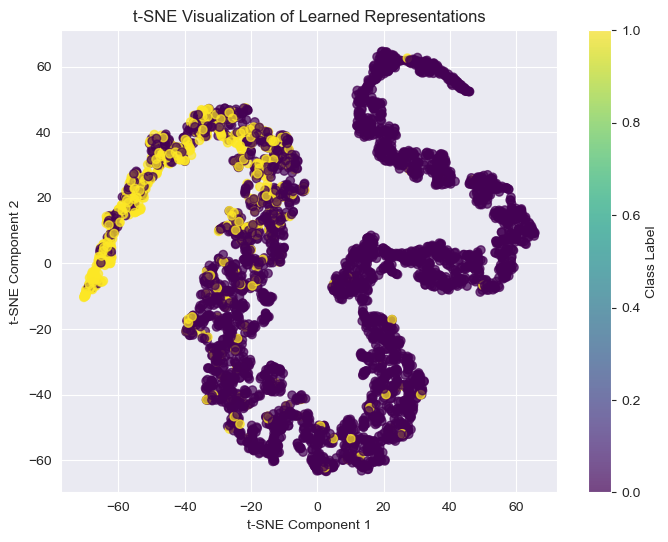

In [168]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Apply t-SNE on the embeddings (2D projection)
tsne = TSNE(n_components=2, random_state=42, verbose=1)
X_train_tsne = tsne.fit_transform(X_train_embeddings)

# Visualize the t-SNE result for the training data
plt.figure(figsize=(8, 6))
plt.scatter(X_train_tsne[:, 0], X_train_tsne[:, 1], c=y_train, cmap='viridis', alpha=0.7)
plt.colorbar(label='Class Label')
plt.title('t-SNE Visualization of Learned Representations')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()


UMAP(n_jobs=1, random_state=42, verbose=1)
Fri Apr  4 01:27:39 2025 Construct fuzzy simplicial set


/Users/tnorlha/miniconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Fri Apr  4 01:27:43 2025 Finding Nearest Neighbors
Fri Apr  4 01:27:44 2025 Finished Nearest Neighbor Search
Fri Apr  4 01:27:44 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Fri Apr  4 01:27:48 2025 Finished embedding


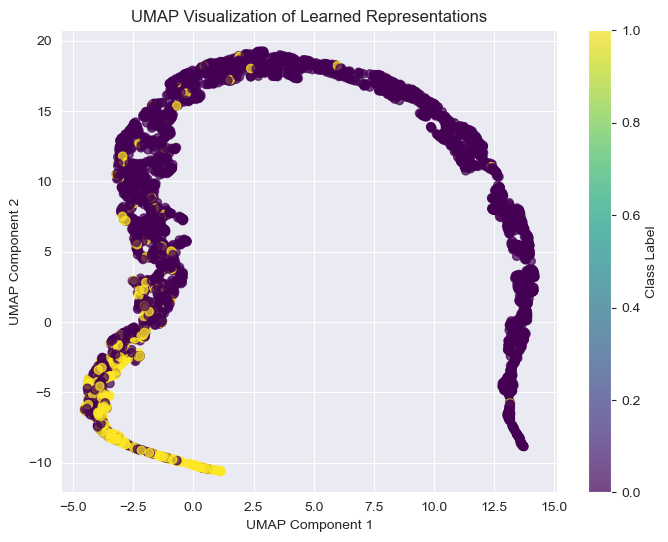

In [169]:
import umap
import matplotlib.pyplot as plt

# Apply UMAP on the embeddings (2D projection)
umap_model = umap.UMAP(n_components=2, random_state=42, verbose=1)
X_train_umap = umap_model.fit_transform(X_train_embeddings)

# Visualize the UMAP result for the training data
plt.figure(figsize=(8, 6))
plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], c=y_train, cmap='viridis', alpha=0.7)
plt.colorbar(label='Class Label')
plt.title('UMAP Visualization of Learned Representations')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.show()


In [171]:
from sklearn.metrics import silhouette_score

# Calculate silhouette score for t-SNE
silhouette_tsne = silhouette_score(X_train_tsne, y_train)
print(f"Silhouette Score (t-SNE): {silhouette_tsne:.4f}")

# Calculate silhouette score for UMAP
silhouette_umap = silhouette_score(X_train_umap, y_train)
print(f"Silhouette Score (UMAP): {silhouette_umap:.4f}")

Silhouette Score (t-SNE): 0.1454
Silhouette Score (UMAP): 0.1833
